This week I learned four SVM kernels — **linear**, **polynomial**, **RBF (Gaussian)**, and **sigmoid**. Rather than re-derive them, I want to *see* the shapes each one can carve out of the plane, so I can pick a kernel sensibly later.

**The idea.** An SVM's decision function is

$$h(\mathbf{x}) = \sum_{i} \alpha_i\, y_i\, K(\mathbf{x}^{(i)}, \mathbf{x}) + b, \qquad \hat{y} = \operatorname{sign}\,h(\mathbf{x}).$$

Each term $K(\mathbf{x}^{(i)}, \cdot)$ is a **basis function** ("landmark") centered on a data point, and $h$ is a weighted sum of them. So the *family of shapes a kernel can express* is exactly what we get by placing landmarks and adding up their kernel fields.

**This is a visualization, not a trained model.** I place the landmarks by hand and set the weights directly — no optimization — because I only care about the **shape** of the surface, not fitting a specific dataset:

- $\alpha_i = 1/n_{\text{class}(i)}$ (each class carries equal total weight). This also makes $\sum_i \alpha_i y_i = 0$ hold, so it's a valid SVM-*form* function — just not the trained optimum.
- $b$ is set to the midpoint between the two classes' median field values — a trivial one-parameter threshold that just slides the boundary to where the classes divide. (We still never train the $\alpha_i$, and we skip the $\pm 1$ margins, which *would* need a genuinely trained model.)
- The decision boundary $\{h=0\}$ is **invariant to scaling** the $\alpha_i$, so the made-up magnitudes don't change its shape — only the choice of $b$ moves it.

Coordinates are kept in a normalized range $[-3.5, 3.5]$: the kernel scale ($\gamma$, `coef0`, `degree`) interacts with the data scale, so it's cleaner to fix one and vary the other.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = False

# The plane on which we evaluate the decision surface h(x).
LO, HI, N = -3.5, 3.5, 400
gx, gy = np.meshgrid(np.linspace(LO, HI, N), np.linspace(LO, HI, N))
GRID = np.column_stack([gx.ravel(), gy.ravel()])   # shape (N*N, 2)

# A coarser grid for the 3D surface plots (keeps them light).
N3 = 90
g3x, g3y = np.meshgrid(np.linspace(LO, HI, N3), np.linspace(LO, HI, N3))
GRID3 = np.column_stack([g3x.ravel(), g3y.ravel()])

## The four kernels

Each kernel takes a batch of points `X` (shape `(M, 2)`) and a set of landmarks `L` (shape `(K, 2)`) and returns the `(M, K)` matrix of $K(\mathbf{x}, \boldsymbol{\ell})$ values. In words:

| Kernel | Formula | Depends on | Shape it contributes |
|---|---|---|---|
| Linear | $\mathbf{x}\cdot\boldsymbol{\ell}$ | direction of $\boldsymbol{\ell}$ | a flat **ramp** (boundaries are straight) |
| Polynomial | $(\gamma\,\mathbf{x}\cdot\boldsymbol{\ell} + c_0)^d$ | direction of $\boldsymbol{\ell}$ | polynomial **bowls / saddles** (conics for $d{=}2$) |
| RBF | $\exp(-\gamma\lVert\mathbf{x}-\boldsymbol{\ell}\rVert^2)$ | **distance** to $\boldsymbol{\ell}$ | a localized **bump** (can enclose regions) |
| Sigmoid | $\tanh(\gamma\,\mathbf{x}\cdot\boldsymbol{\ell} + c_0)$ | direction of $\boldsymbol{\ell}$ | an S-shaped **ridge** |

In [2]:
def k_linear(X, L):
    """K(x, l) = x . l  — a plain inner product (a ramp in the direction of l)."""
    return X @ L.T

def k_poly(X, L, gamma=0.5, coef0=1.0, degree=3):
    """K(x, l) = (gamma * x.l + coef0) ** degree  — polynomial surfaces."""
    return (gamma * (X @ L.T) + coef0) ** degree

def k_rbf(X, L, gamma=0.6):
    """K(x, l) = exp(-gamma * ||x - l||^2)  — a localized Gaussian bump at l."""
    sq = (X**2).sum(1)[:, None] + (L**2).sum(1)[None, :] - 2 * (X @ L.T)
    return np.exp(-gamma * np.maximum(sq, 0.0))

def k_sigmoid(X, L, gamma=0.4, coef0=-1.0):
    """K(x, l) = tanh(gamma * x.l + coef0)  — an S-shaped ridge (not always PSD)."""
    return np.tanh(gamma * (X @ L.T) + coef0)

In [3]:
def balanced_alpha(y):
    """alpha_i = 1 / (size of its class), so each class carries equal total weight
    (this also makes sum_i alpha_i * y_i = 0)."""
    y = np.asarray(y, float)
    alpha = np.ones_like(y)
    for c in (-1.0, 1.0):
        m = y == c
        if m.any():
            alpha[m] = 1.0 / m.sum()
    return alpha

def _raw_field(points, landmarks, y, kernel, b=0.0):
    """f(x) = sum_i alpha_i y_i K(x_i, x) + b, evaluated at `points`."""
    y = np.asarray(y, float)
    a = balanced_alpha(y)
    return kernel(points, landmarks) @ (a * y) + b

def bias_threshold(landmarks, y, kernel):
    """Pick b as the midpoint between the two classes' median field values —
    a trivial one-parameter threshold. We never train the alpha_i."""
    y = np.asarray(y, float)
    fL = _raw_field(landmarks, landmarks, y, kernel)         # b = 0 at the landmarks
    return -0.5 * (np.median(fL[y == 1]) + np.median(fL[y == -1]))

def decision_field(grid, landmarks, y, kernel):
    """h(x) over the grid, with b chosen so the boundary sits between the classes."""
    b = bias_threshold(landmarks, y, kernel)
    return _raw_field(grid, landmarks, y, kernel, b)

def _scatter(ax, landmarks, y):
    y = np.asarray(y)
    for c, mk, col in [(1, "o", "#b2182b"), (-1, "s", "#2166ac")]:
        m = y == c
        ax.scatter(landmarks[m, 0], landmarks[m, 1], marker=mk, facecolors=col,
                   edgecolors="k", s=70, linewidths=1.2, zorder=3, label=f"y = {c:+d}")

def plot_field(ax, field, landmarks=None, y=None, title=""):
    """Filled heat-map of h(x) with the h=0 decision boundary in black."""
    Z = field.reshape(gx.shape)
    maxabs = float(np.abs(Z).max())
    if maxabs < 1e-9:                    # degenerate (e.g. linear on a symmetric set)
        ax.imshow(np.zeros_like(Z), extent=[LO, HI, LO, HI], origin="lower",
                  cmap="RdBu_r", vmin=-1, vmax=1)
        ax.text(0.5, 0.5, "field ≈ 0\n(cannot separate)", transform=ax.transAxes,
                ha="center", va="center", fontsize=11, color="#444")
    else:
        norm = TwoSlopeNorm(vmin=-maxabs, vcenter=0.0, vmax=maxabs)
        ax.contourf(gx, gy, Z, levels=40, cmap="RdBu_r", norm=norm)
        ax.contour(gx, gy, Z, levels=[0.0], colors="k", linewidths=2.0)
    if landmarks is not None:
        _scatter(ax, landmarks, y)
    ax.set_xlim(LO, HI); ax.set_ylim(LO, HI); ax.set_aspect("equal")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title(title)

def show_kernels(landmarks, y, kernels, suptitle):
    """2x2 panel of decision surfaces for the four kernels on one dataset."""
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.6))
    for ax, (name, kern) in zip(axes.ravel(), kernels):
        field = decision_field(GRID, landmarks, y, kern)
        plot_field(ax, field, landmarks, y, title=name)
    axes[0, 0].legend(loc="upper right", fontsize=8, framealpha=0.9)
    fig.suptitle(suptitle, y=0.99, fontsize=13)
    plt.tight_layout()
    plt.show()

## 1. One landmark = one basis shape

The most atomic view: place a **single landmark** $\boldsymbol{\ell}$ (the black star) and plot its raw kernel field $K(\boldsymbol{\ell}, \mathbf{x})$ over the plane. This is the building block every decision surface is summed from.

Notice the fundamental split: **linear / polynomial / sigmoid** depend on $\mathbf{x}\cdot\boldsymbol{\ell}$ (the *direction* of $\boldsymbol{\ell}$), so their fields are ramps/ridges. **RBF** depends on the *distance* $\lVert\mathbf{x}-\boldsymbol{\ell}\rVert$, so it is a localized bump — that locality is exactly what lets RBF enclose regions.

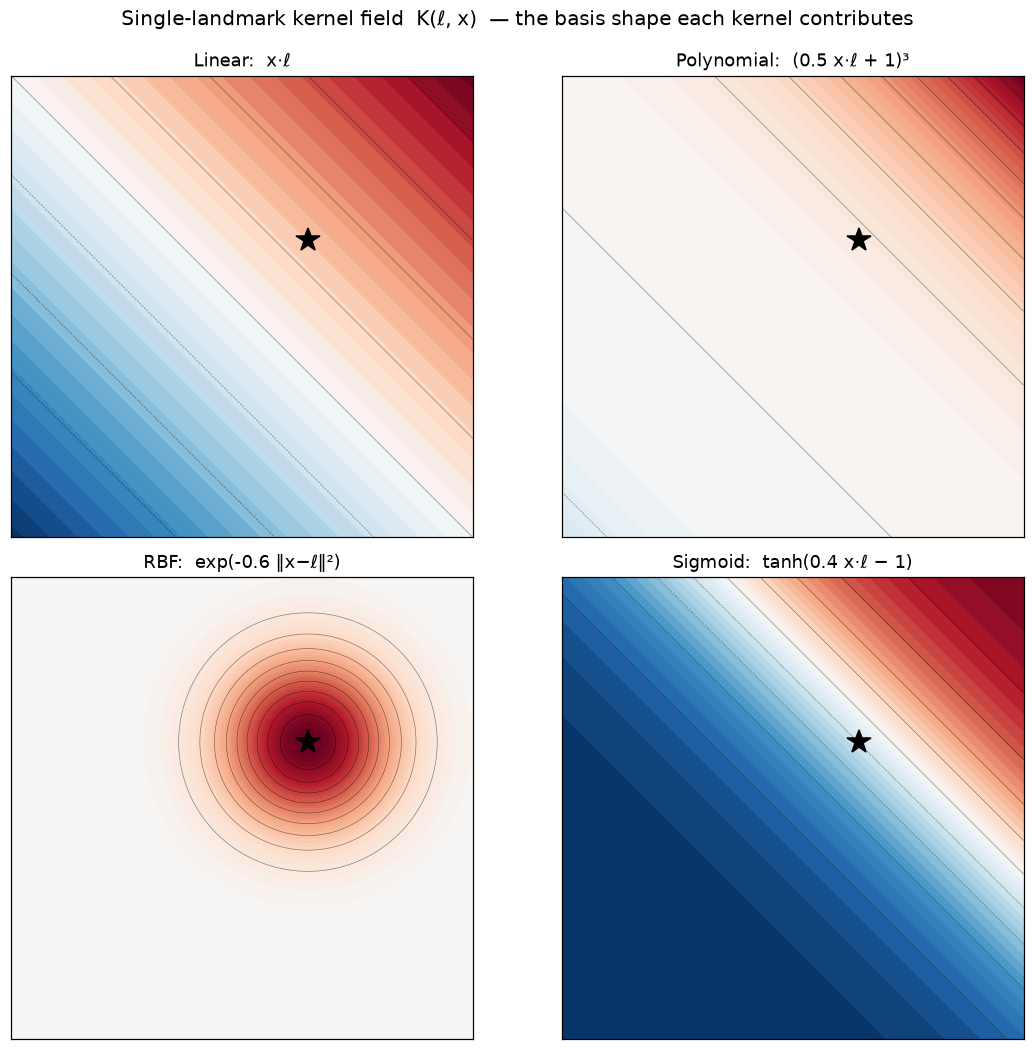

In [4]:
L0 = np.array([[1.0, 1.0]])   # a single landmark, off-origin so linear/poly aren't constant
panels = [
    ("Linear:  x·ℓ",                     lambda X: k_linear(X, L0)),
    ("Polynomial:  (0.5 x·ℓ + 1)³",      lambda X: k_poly(X, L0)),
    ("RBF:  exp(-0.6 ‖x−ℓ‖²)",           lambda X: k_rbf(X, L0)),
    ("Sigmoid:  tanh(0.4 x·ℓ − 1)",      lambda X: k_sigmoid(X, L0)),
]

fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.6))
for ax, (name, fn) in zip(axes.ravel(), panels):
    Z = fn(GRID).reshape(gx.shape)
    vmax = float(np.abs(Z).max()) or 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    ax.contourf(gx, gy, Z, levels=40, cmap="RdBu_r", norm=norm)
    ax.contour(gx, gy, Z, levels=10, colors="k", linewidths=0.4, alpha=0.5)
    ax.plot(*L0[0], marker="*", color="k", ms=16, zorder=3)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.set_title(name)
fig.suptitle("Single-landmark kernel field  K(ℓ, x)  — the basis shape each kernel contributes",
             y=0.99, fontsize=13)
plt.tight_layout(); plt.show()

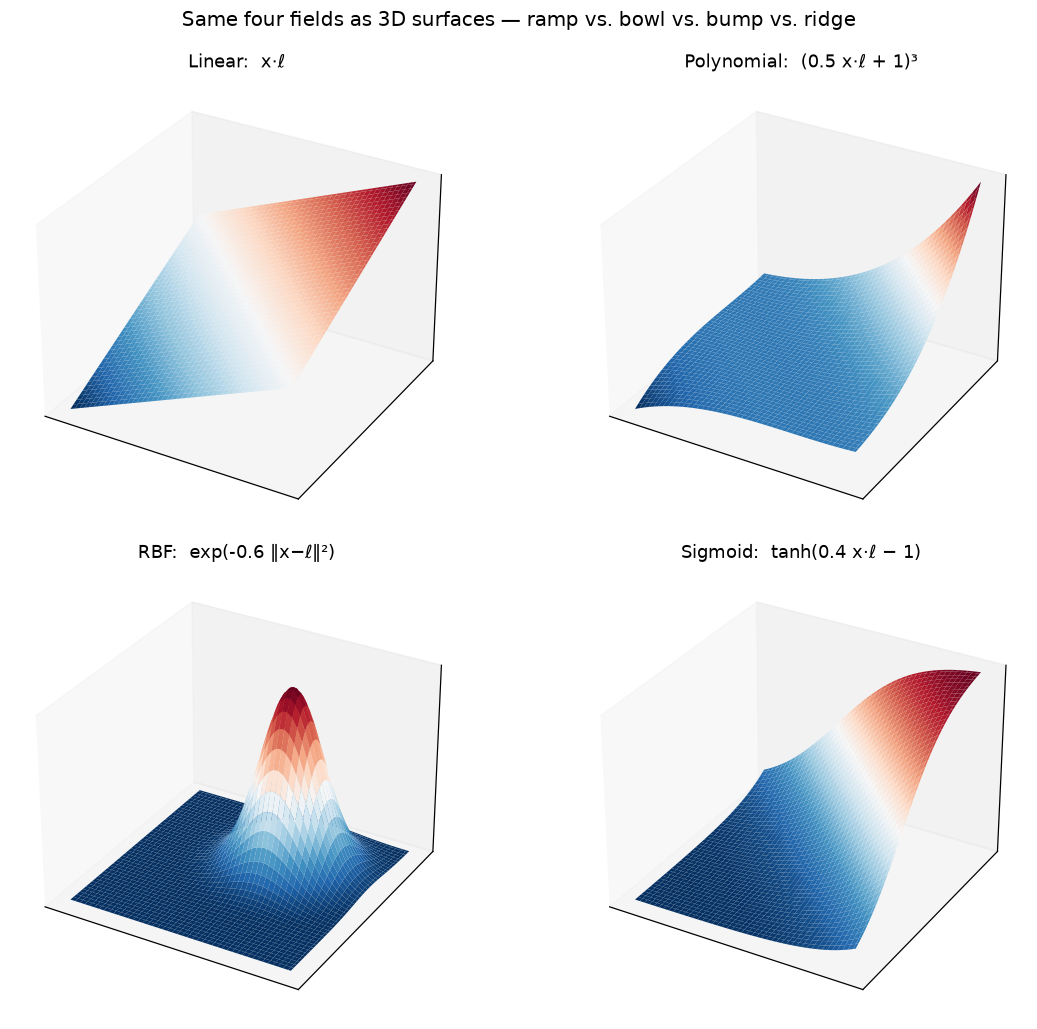

In [5]:
fig = plt.figure(figsize=(11, 9.4))
for i, (name, fn) in enumerate(panels):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    Z = fn(GRID3).reshape(g3x.shape)
    ax.plot_surface(g3x, g3y, Z, cmap="RdBu_r", linewidth=0, antialiased=True)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
fig.suptitle("Same four fields as 3D surfaces — ramp vs. bowl vs. bump vs. ridge",
             y=0.99, fontsize=13)
plt.tight_layout(); plt.show()

## 2. Concentric rings — can the kernel *enclose* a class?

Here one class (red, $+1$) sits at the center, **surrounded** by the other (blue, $-1$). A straight line can never separate these, so this is the classic test of whether a kernel can bend a boundary into a **closed loop**.

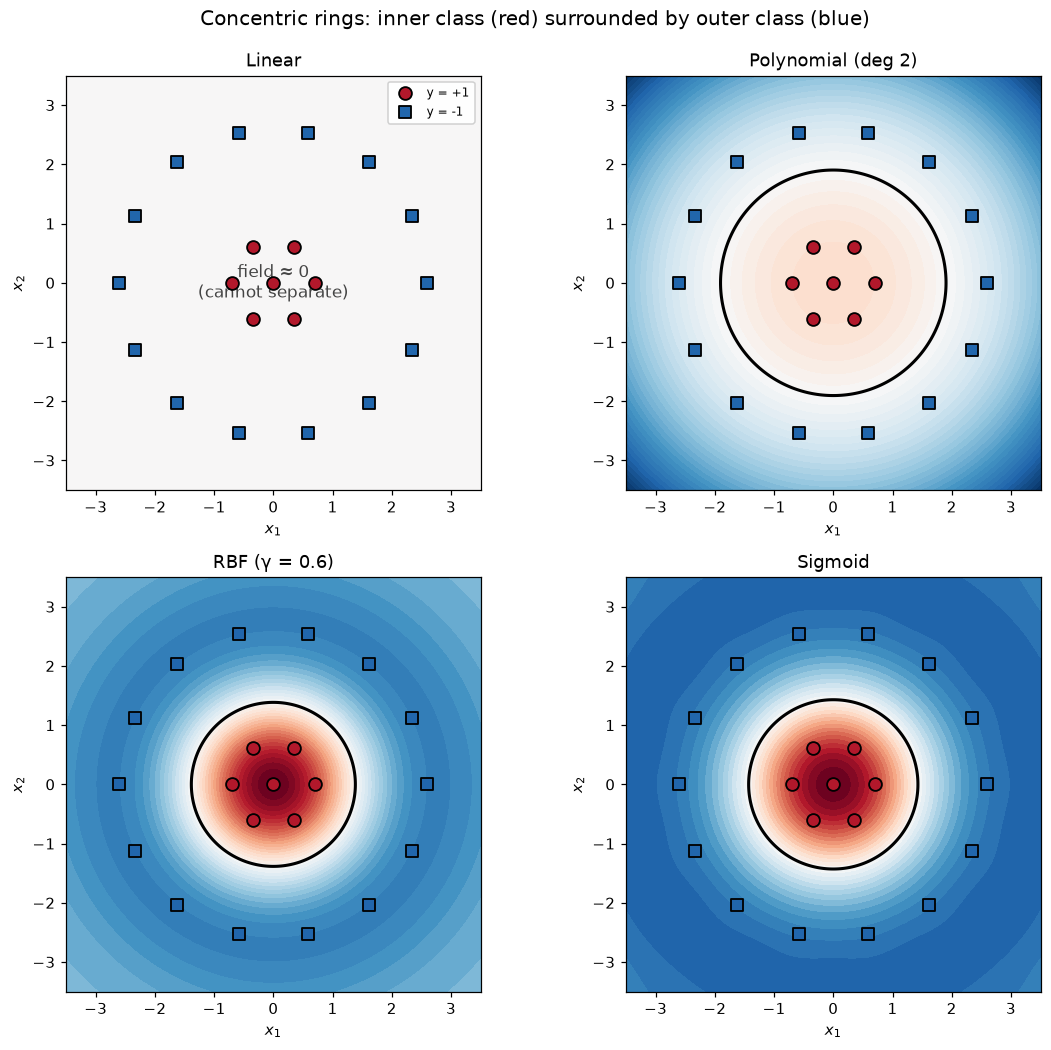

In [6]:
def ring(n, r, label, phase=0.0):
    t = np.linspace(0, 2 * np.pi, n, endpoint=False) + phase
    return np.column_stack([r * np.cos(t), r * np.sin(t)]), np.full(n, label)

inner_r, inner_yl = ring(6, 0.7, +1)
inner = np.vstack([[[0.0, 0.0]], inner_r])          # center + small ring  (class +1)
inner_y = np.concatenate([[+1], inner_yl])
outer, outer_y = ring(14, 2.6, -1)                  # big ring             (class -1)

ring_L = np.vstack([inner, outer])
ring_y = np.concatenate([inner_y, outer_y])

ring_kernels = [
    ("Linear",                lambda X, L: k_linear(X, L)),
    ("Polynomial (deg 2)",    lambda X, L: k_poly(X, L, gamma=0.5, coef0=1.0, degree=2)),
    ("RBF (γ = 0.6)",         lambda X, L: k_rbf(X, L, gamma=0.6)),
    ("Sigmoid",               lambda X, L: k_sigmoid(X, L, gamma=0.4, coef0=-1.0)),
]
show_kernels(ring_L, ring_y, ring_kernels,
             "Concentric rings: inner class (red) surrounded by outer class (blue)")

**What to read here.** The **RBF** kernel wraps a clean closed loop around the inner class — its local bumps pile up in the center and fade outward. Once the bias $b$ is placed between the classes, the **polynomial** (degree 2) and even the **sigmoid** also manage to enclose the center here, because the landmarks are radially symmetric (the polynomial's loop is a conic — roughly a circle/ellipse). The **linear** kernel is the one that truly collapses: the two classes share the same center of mass, so $\sum_i \alpha_i y_i \mathbf{x}^{(i)} \approx \mathbf{0}$ and the field is essentially flat — it *cannot* represent "surrounded" no matter where we put $b$.

## 3. Interleaved blobs — a layout where "straight" isn't enough

Two red ($+1$) clusters flank a blue ($-1$) cluster in the middle. Again the class means roughly coincide, so a single straight line can't carve out the middle — but curved boundaries can.

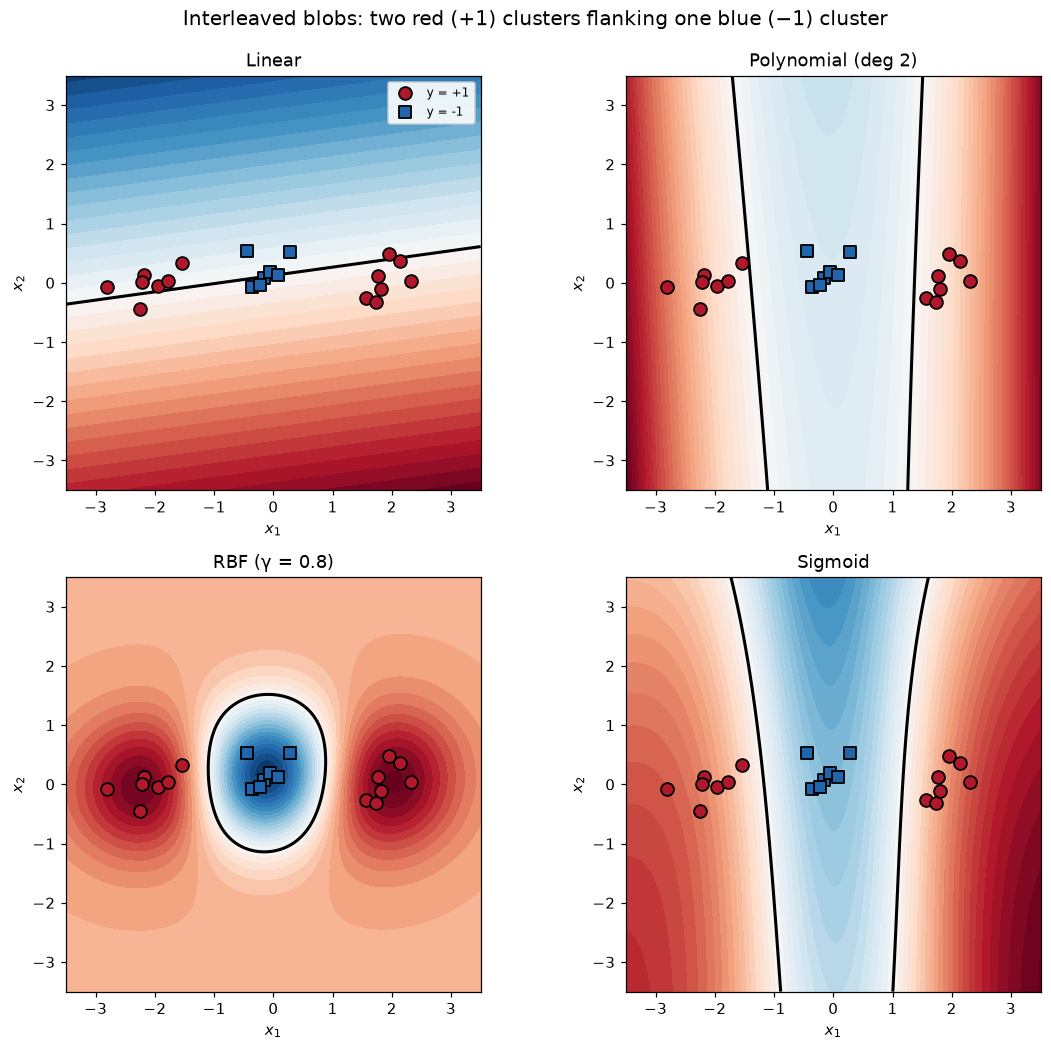

In [7]:
rng = np.random.default_rng(0)
def blob(center, n=7, spread=0.35, label=+1):
    pts = np.array(center) + spread * rng.standard_normal((n, 2))
    return pts, np.full(n, label)

bL1, by1 = blob((-2.0,  0.0), label=+1)
bL2, by2 = blob(( 2.0,  0.0), label=+1)
bL3, by3 = blob(( 0.0,  0.0), label=-1)
blob_L = np.vstack([bL1, bL2, bL3])
blob_y = np.concatenate([by1, by2, by3])

blob_kernels = [
    ("Linear",              lambda X, L: k_linear(X, L)),
    ("Polynomial (deg 2)",  lambda X, L: k_poly(X, L, gamma=0.5, coef0=1.0, degree=2)),
    ("RBF (γ = 0.8)",       lambda X, L: k_rbf(X, L, gamma=0.8)),
    ("Sigmoid",             lambda X, L: k_sigmoid(X, L, gamma=0.4, coef0=-1.0)),
]
show_kernels(blob_L, blob_y, blob_kernels,
             "Interleaved blobs: two red (+1) clusters flanking one blue (−1) cluster")

**What to read here.** **RBF** isolates the middle blue region as a pocket between the two red clusters. The **polynomial** bends into a band/strip that peels the middle from the flanks. **Linear** again can only offer a single straight cut, which cannot separate a middle class from two outer ones. **Sigmoid** gives a soft, sometimes unstable partition.

## Choosing a kernel — a quick mental model

| Kernel | Boundary shapes | Key knob(s) | Reach for it when… |
|---|---|---|---|
| **Linear** | straight lines / hyperplanes only | (none) | data is (nearly) linearly separable; high-dimensional/sparse features; you want speed + interpretability |
| **Polynomial** | conics & higher-order curves | `degree`, `coef0`, `gamma` | you expect smooth, global curvature or feature interactions of a known order |
| **RBF** | localized, closed, very flexible | `gamma` (bump width) | a strong, general-purpose default; classes form blobs/pockets; boundary is irregular |
| **Sigmoid** | S-shaped ridges (NN-like) | `gamma`, `coef0` | rarely first choice; mimics a 2-layer net — but see caveat below |

**Caveats I want to remember**

- **Scale matters.** Every kernel except linear has a $\gamma$ that must match the data scale. Too large ⇒ tiny bumps that overfit; too small ⇒ almost linear. (This is why I normalized coordinates above.)
- **RBF `gamma` = curviness.** Bigger $\gamma$ ⇒ smaller bumps ⇒ wigglier, more local boundaries.
- **Sigmoid isn't always a valid (Mercer/PSD) kernel** — for some $\gamma, c_0$ it doesn't correspond to a real inner-product feature space, which is why it can behave erratically.
- These are **expressiveness sketches**, not trained models — real training picks the $\alpha_i$ and $b$, and adds a soft margin (`C`) to trade off margin width against errors.

## Acknowledgment

This visual exploration accompanies my notes for **24-887 — Machine Learning & Artificial Intelligence for Engineers**, taught by Professor Levent Burak Kara as part of Carnegie Mellon University's [AI Engineering Fundamentals](https://www.cmu.edu/online/ai-engineering-fundamentals) graduate certificate. Credit for the course material goes to the instructor and CMU; the hand-built visualizations and any errors here are my own.